In [1]:
import numpy as np
import librosa
import matplotlib.pyplot as plt


In [3]:
frame_len = 2048
hop_len = 512
audio_path = "/content/ml_project.m4a"

def load_audio(path):
  y, sr = librosa.load(path, sr=None)
  return y, sr

y, sr = load_audio(audio_path)
print(f"Loaded {len(y)/sr:.2f}s of audio at {sr}Hz")

/tmp/ipykernel_12802/644642842.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=None)


Loaded 19.52s of audio at 48000Hz


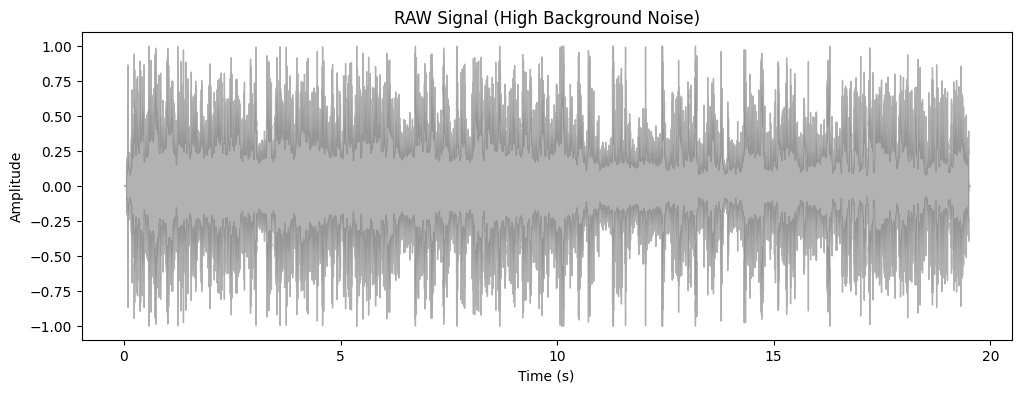

In [4]:
import librosa.display
plt.figure(figsize=(12,4))
librosa.display.waveshow(y, sr=sr, color='gray', alpha=0.6)
plt.title("RAW Signal (High Background Noise)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

In [5]:
def extract_feat(y, sr):
  #RMS: Measures Energy
  rms = librosa.feature.rms(y=y, frame_length=frame_len, hop_length=hop_len)[0]

  #Spectral Centroid: Measures "brightness" or frequency center
  sc = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hop_len)[0]

  #ZCR: Measures how noisy the signal is
  zcr = librosa.feature.zero_crossing_rate(y=y, frame_length=frame_len, hop_length=hop_len)[0]


  times = librosa.times_like(rms, sr=sr, hop_length=hop_len)
  return {"rms": rms, "sc":sc, "zcr":zcr, "times":times}

features = extract_feat(y, sr)




In [6]:
WEIGHTS = {"rms": 0.5, "sc": 0.3, "zcr": 0.2}

def zscore(x):
 ##Measures how many "standard deviations" a point is from the mean

 return (x - x.mean()) / (x.std() + 1e-8)


def compute_anomaly_score(f):
  rms_z = zscore(f["rms"])
  sc_z = zscore(f["sc"])
  zcr_z = zscore(f["zcr"])

  return (WEIGHTS["rms"] * rms_z) + (WEIGHTS["sc"] * sc_z) + (WEIGHTS["zcr"] * zcr_z)


score = compute_anomaly_score(features)


In [11]:
from scipy.signal import find_peaks
import json
import time

Thresh_Mult = 2.0     ##It is a Statistical threshold (Top ~5% of deviations or covers 95% of the data)
Min_Gap_Sec = 0.3     ##Minimum Gap between two events ttoo close

##Calculating the threshold
thresh = score.mean() + Thresh_Mult * score.std()

##Finding Peaks ( the actual frames wherre spikes happened)

peaks, _  = find_peaks(score, height=thresh, distance=Min_Gap_Sec * len(score) / features['times'][-1])


events = []

if len(peaks):
    group = [peaks[0]]
    for p in peaks[1:]:
        if features['times'][p] - features['times'][group[-1]] <= Min_Gap_Sec:
            group.append(p)
        else:
            start = round(max(0.0, float(features['times'][group[0]])  - 0.05), 2)
            end   = round(float(features['times'][group[-1]]) + 0.05, 2)
            events.append({"start": start, "end": end})
            group = [p]
    start = round(max(0.0, float(features['times'][group[0]])  - 0.05), 2)
    end   = round(float(features['times'][group[-1]]) + 0.05, 2)
    events.append({"start": start, "end": end})

print(f"Detected {len(events)} events")
print(json.dumps(events, indent=2))

Detected 9 events
[
  {
    "start": 0.0,
    "end": 0.08
  },
  {
    "start": 0.66,
    "end": 0.76
  },
  {
    "start": 1.14,
    "end": 1.24
  },
  {
    "start": 6.67,
    "end": 6.77
  },
  {
    "start": 7.32,
    "end": 7.42
  },
  {
    "start": 10.06,
    "end": 10.16
  },
  {
    "start": 13.14,
    "end": 13.24
  },
  {
    "start": 14.28,
    "end": 14.38
  },
  {
    "start": 16.22,
    "end": 16.32
  }
]


In [13]:
min_dist   = int(Min_Gap_Sec * sr / hop_len)

runs = []
for _ in range(10):
    t0 = time.perf_counter()
    feats = extract_feat(y, sr)
    s     = compute_anomaly_score(feats)
    find_peaks(s, height=s.mean() + Thresh_Mult * s.std(), distance=min_dist)
    runs.append(time.perf_counter() - t0)

import numpy as np
print(f"\nAvg inference latency: {np.mean(runs)*1000:.1f} ms  (over 10 runs)")


Avg inference latency: 54.6 ms  (over 10 runs)


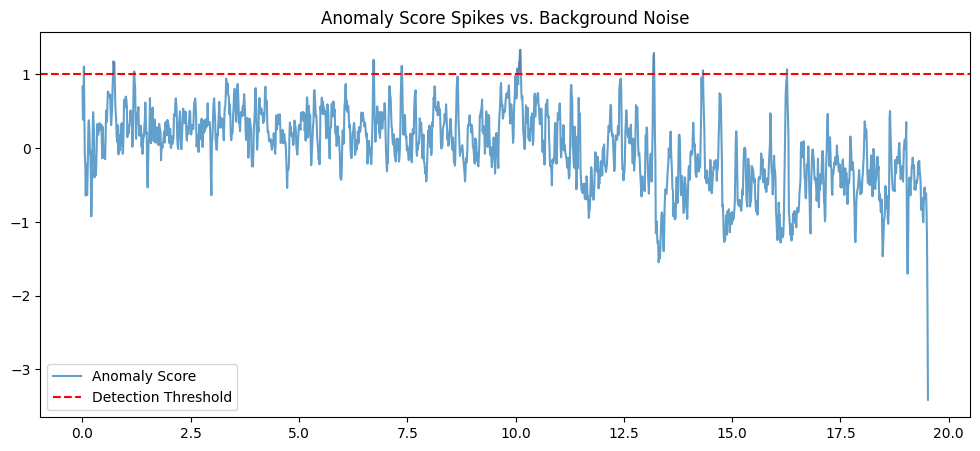

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(features['times'], score, label="Anomaly Score", alpha=0.7)
plt.axhline(y=thresh, color='r', linestyle='--', label="Detection Threshold")
plt.fill_between(features['times'], score, thresh, where=(score > thresh), color='red', alpha=0.3)
plt.title("Anomaly Score Spikes vs. Background Noise")
plt.legend()
plt.show()

In [15]:
with open('detected_events.json','w') as f:
  json.dump(events, f, indent=2)